# =================================================
# Paso 4: APRENDIZAJE POR REFUERZO (Q-LEARNING) HÍBRIDO
# =================================================


### 1. Arquitectura Híbrida: CNN + RL Clásico

En este paso, conectamos el "ojo" con el "cerebro".
1. **Ojo (Percepción):** Cargamos el modelo Deep Learning (`modelo_cnn.keras`) para que evalúe nuestro dataset real de imágenes.
2. **Cerebro (Decisión):** Usamos la secuencia de estados predichos por la CNN para entrenar nuestro algoritmo de Q-Learning. De esta forma, el agente aprende sobre la transición real de aforos (ej. un bus "Vacío" suele pasar a "Medio", rara vez salta directamente a "Lleno")

In [ ]:
!pip install tensorflow

---
### 2. Importar librerías

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


---
### 3. Cargar el Dataset y el Modelo CNN (Predicción de Estados)

In [ ]:
print("--- 1. EXTRACCIÓN DE ESTADOS DESDE LA CNN ---")
# Montar Google Drive
drive.mount('/content/drive')

# Rutas definidas de tu entorno
ruta_csv = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/df_imagenes_preprocesado.csv'
dir_destino = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/imagenes_bus'
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
ruta_archivo_cnn = os.path.join(ruta_resultados, 'modelo_cnn.keras')

# 1. Cargar el modelo CNN
print(f"Cargando modelo CNN desde: {ruta_archivo_cnn}")
modelo_cnn = load_model(ruta_archivo_cnn)

# 2. Cargar el dataset tabular (CSV con las rutas de las imágenes)
df_imagenes = pd.read_csv(ruta_csv)

# 3. Preparar el generador de imágenes (asumiendo que las imágenes ya están preprocesadas)
# Ajusta el 'x_col' o 'y_col' según cómo se llamen en tu CSV
# 3. Preparar el generador de imágenes
datagen = ImageDataGenerator(rescale=1./255)

generador_imagenes = datagen.flow_from_dataframe(
    dataframe=df_imagenes,
    directory=None,             # ¡MUY IMPORTANTE! Ponemos None porque el CSV ya tiene la ruta completa
    x_col='ruta_imagen',
    y_col=None,
    target_size=(150, 150),
    class_mode=None,
    shuffle=False,              # Mantener en False para la secuencia del Q-Learning
    batch_size=32
)

# 4. Obtener las predicciones (Estados: 0=Vacío, 1=Medio, 2=Lleno)
print("Generando predicciones sobre el dataset de imágenes...")
predicciones_prob = modelo_cnn.predict(generador_imagenes)
secuencia_estados = np.argmax(predicciones_prob, axis=1)

estados_labels = ['Vacío', 'Medio', 'Lleno']
print(f"Predicciones extraídas: {len(secuencia_estados)} estados (ej. {secuencia_estados[:5]})")

--- 1. EXTRACCIÓN DE ESTADOS DESDE LA CNN ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando modelo CNN desde: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/modelo_cnn.keras
Found 1144 validated image filenames.
Generando predicciones sobre el dataset de imágenes...
36/36 ━━━━━━━━━━━━━━━━━━━━ 281s 8s/step
Predicciones extraídas: 1144 estados (ej. [2 2 2 2 2])



---
### 4. Definición del Entorno (MDP basado en datos reales)


In [ ]:
print("--- 2. CONFIGURACIÓN DEL ENTORNO RL ---")

# Acciones posibles de negocio
acciones = ['Normal', 'Saltar_Parada', 'Enviar_Refuerzo']

# Matriz de Recompensas (Rewards)
# Filas = Estados (Vacío, Medio, Lleno), Columnas = Acciones
R = np.array([
    [ 10, -10, -20],  # Si CNN dice Vacío: Normal (+10), Saltar (-10), Refuerzo (-20)
    [ 10,  -5,  -5],  # Si CNN dice Medio: Normal (+10), Saltar (-5), Refuerzo (-5)
    [-20,  10,  20]   # Si CNN dice Lleno: Normal (-20), Saltar (+10), Refuerzo (+20)
])

# Q-Table inicializada a ceros (Estados x Acciones)
Q = np.zeros((len(estados_labels), len(acciones)))

print("Matriz de Recompensas y Q-Table inicializadas.")

--- 2. CONFIGURACIÓN DEL ENTORNO RL ---
Matriz de Recompensas y Q-Table inicializadas.



---
### 5. Entrenamiento Q-Learning (Iterando sobre la realidad capturada)
El agente recorrerá las predicciones de la CNN de forma secuencial múltiples veces (épocas), aprendiendo las dinámicas reales del dataset.


In [ ]:
print("--- 3. ENTRENAMIENTO Q-LEARNING SOBRE DATOS REALES ---")

# Hiperparámetros
alpha = 0.1       # Learning rate
gamma = 0.9       # Factor de descuento
epsilon = 0.2     # Epsilon-greedy
epocas_rl = 500   # Pasadas completas sobre la secuencia de datos reales

for epoca in range(epocas_rl):
    # Recorremos la secuencia de predicciones de la CNN (evitando simulaciones)
    for t in range(len(secuencia_estados) - 1):
        estado_actual = secuencia_estados[t]
        estado_siguiente = secuencia_estados[t+1] # El dataset nos dice qué pasó realmente después

        # Estrategia Epsilon-Greedy
        if np.random.uniform(0, 1) < epsilon:
            accion = np.random.randint(0, len(acciones)) # Explorar
        else:
            accion = np.argmax(Q[estado_actual, :])      # Explotar

        # Recompensa obtenida
        recompensa = R[estado_actual, accion]

        # Ecuación de Bellman
        Q[estado_actual, accion] = Q[estado_actual, accion] + \
            alpha * (recompensa + gamma * np.max(Q[estado_siguiente, :]) - Q[estado_actual, accion])

print("Entrenamiento completado exitosamente.")

--- 3. ENTRENAMIENTO Q-LEARNING SOBRE DATOS REALES ---
Entrenamiento completado exitosamente.



---
### 6. Guardado del Pipeline para XAI y Visualización



--- 4. EXPORTACIÓN DEL MODELO Y MATRIZ DE CONFIANZA ---
✅ Pipeline Q-Learning guardado optimizado en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/modelo_qlearning_pipeline.joblib


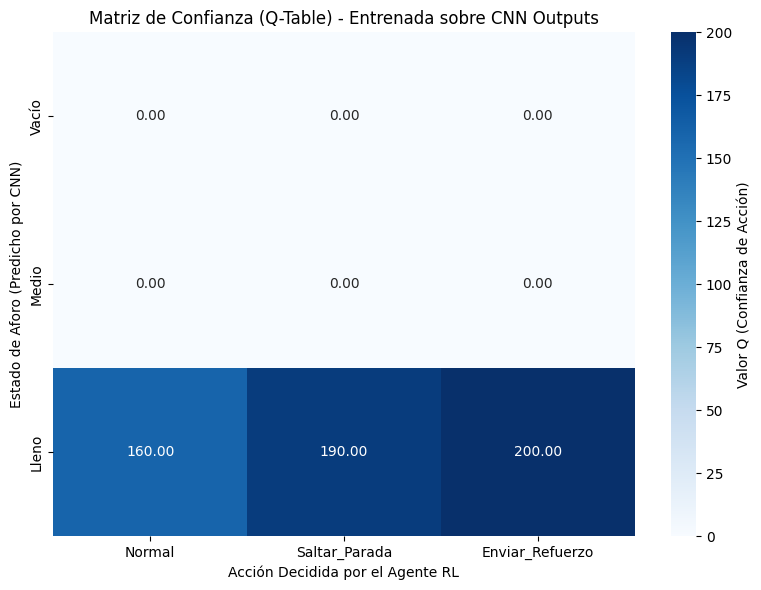


--- RESUMEN DE LA POLÍTICA DE RUTEO DEFINITIVA ---
Si la CNN detecta [Vacío] ---> La decisión de negocio es: [Normal]
Si la CNN detecta [Medio] ---> La decisión de negocio es: [Normal]
Si la CNN detecta [Lleno] ---> La decisión de negocio es: [Enviar_Refuerzo]


In [ ]:
print("--- 4. EXPORTACIÓN DEL MODELO Y MATRIZ DE CONFIANZA ---")

# 1. GUARDAR PIPELINE EN .JOBLIB
ruta_archivo_q = os.path.join(ruta_resultados, 'pipeline_qlearning.joblib')

pipeline_xai = {
    'Q_table': Q,
    'estados': estados_labels,
    'acciones': acciones,
    'recompensas': R
}

joblib.dump(pipeline_xai, ruta_archivo_q)
print(f"✅ Pipeline Q-Learning guardado optimizado en: {ruta_archivo_q}")

# 2. GRAFICAR MATRIZ DE CONFIANZA
plt.figure(figsize=(8, 6))
sns.heatmap(Q, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=acciones, yticklabels=estados_labels,
            cbar_kws={'label': 'Valor Q (Confianza de Acción)'})

plt.title("Matriz de Confianza (Q-Table) - Entrenada sobre CNN Outputs")
plt.xlabel("Acción Decidida por el Agente RL")
plt.ylabel("Estado de Aforo (Predicho por CNN)")
plt.tight_layout()
plt.show()

# 3. IMPRIMIR LA POLÍTICA APRENDIDA
print("\n--- RESUMEN DE LA POLÍTICA DE RUTEO DEFINITIVA ---")
for i, estado in enumerate(estados_labels):
    mejor_accion = acciones[np.argmax(Q[i, :])]
    print(f"Si la CNN detecta [{estado}] ---> La decisión de negocio es: [{mejor_accion}]")